WE will 

In [43]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings


warnings.filterwarnings("ignore")


In [44]:
df = pd.read_csv("insurance.csv")


In [45]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA 

In [46]:
df.shape

(1338, 7)

In [47]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [48]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [50]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [51]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [52]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

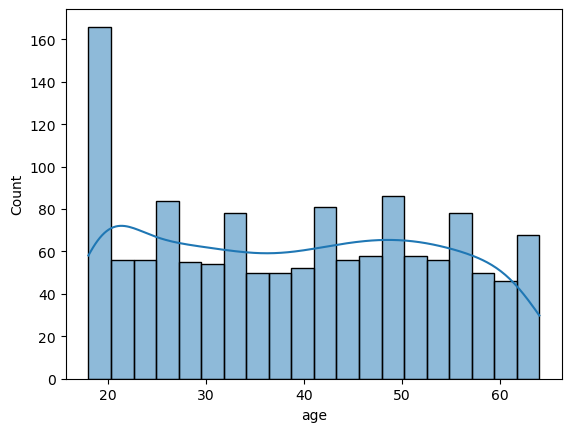

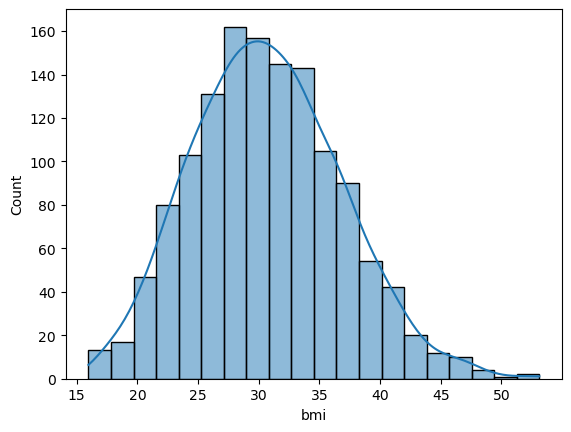

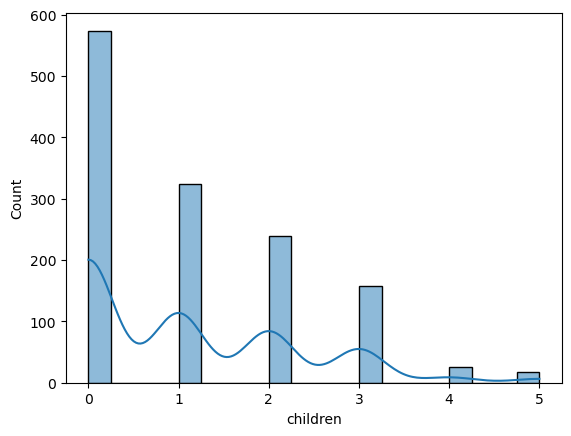

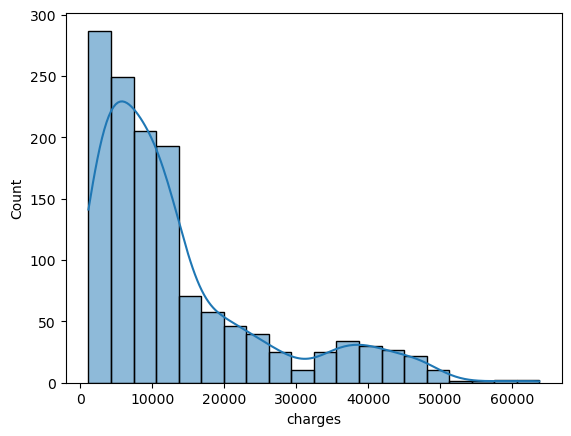

In [53]:
## Visualization 

numaric_column = ['age', 'bmi', 'children','charges']

for col in numaric_column:
    plt.Figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)
    plt.show()

<Axes: xlabel='children', ylabel='count'>

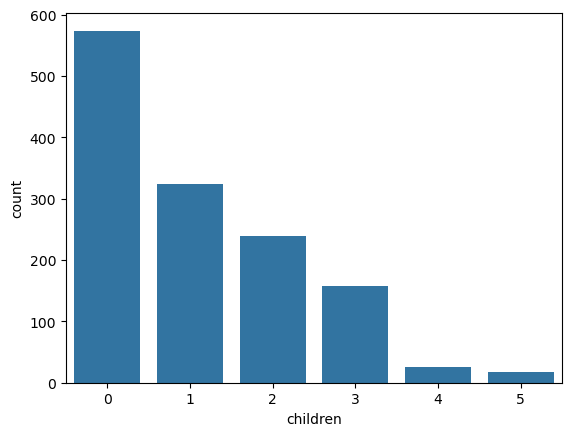

In [54]:
sns.countplot(x = df['children'] )

<Axes: xlabel='sex', ylabel='count'>

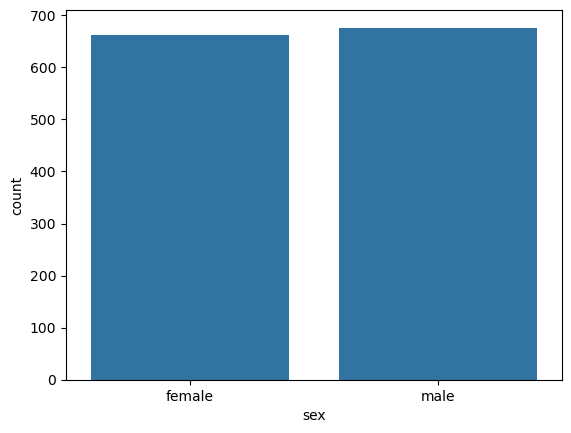

In [55]:
sns.countplot(x=df["sex"])

<Axes: xlabel='count', ylabel='smoker'>

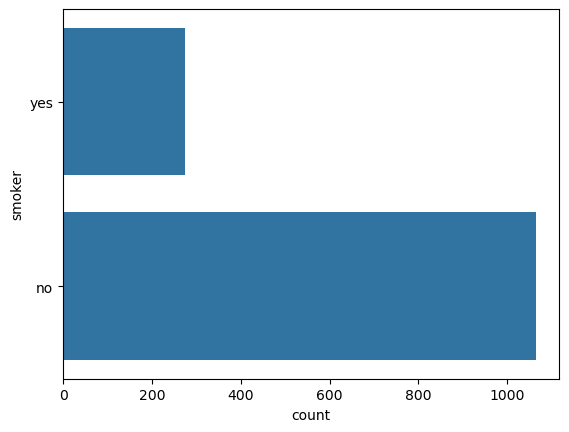

In [56]:
sns.countplot(y=df["smoker"])

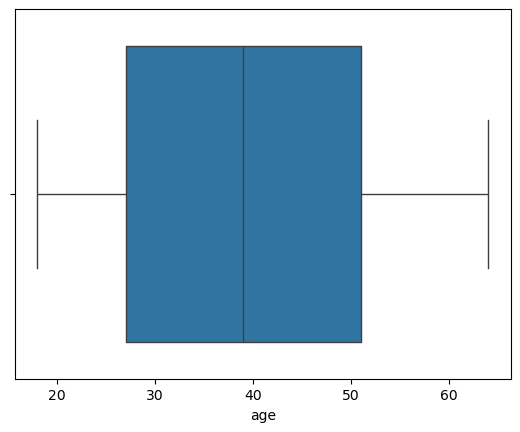

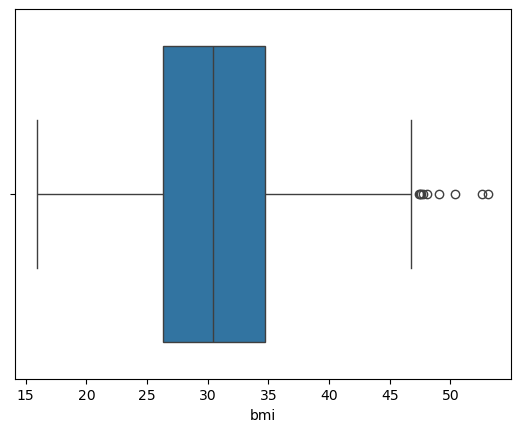

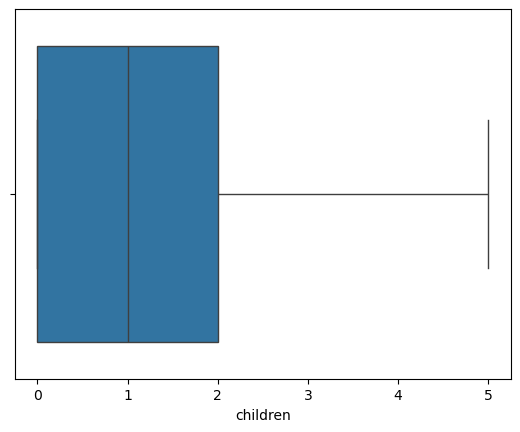

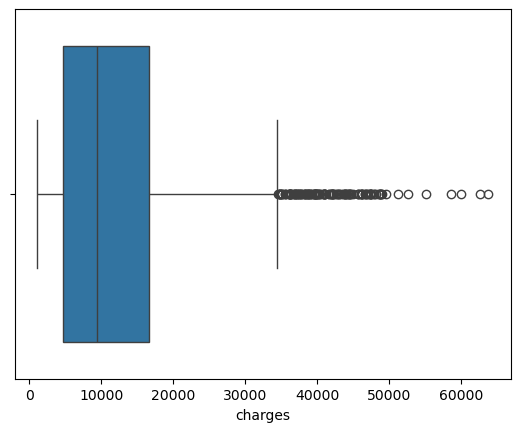

In [57]:
# This is all exploratory data analysis
# lets do make some box plots

for col in numaric_column:
    plt.Figure(figsize=(6,4))
    sns.boxplot(x = df[col])
    plt.show()

<Axes: >

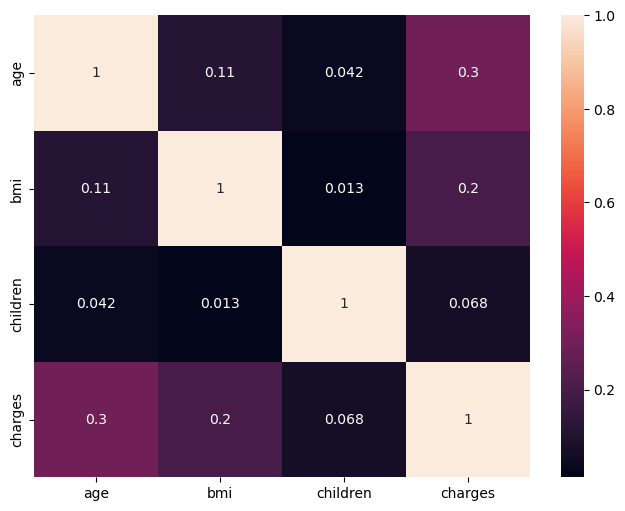

In [58]:
## corelation 

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True)

In [59]:
# Data Cleaning 
# as the data is already cleaned so we dont need to do it 

In [60]:
df_clean = df.copy()

In [61]:
df_clean.drop_duplicates(inplace=True)

In [62]:
df.shape

(1338, 7)

In [63]:
df_clean.shape

(1337, 7)

In [64]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [65]:
df_clean.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [66]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [67]:
# Label encoding for sex 

df_clean['sex'] = df_clean['sex'].map({"male": 0,"female":1})
df_clean.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [68]:
# label encoding smoker

df_clean['smoker'] = df_clean['smoker'].map({"no": 0,"yes":1})

In [69]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [70]:
df_clean.rename(columns = {
    'sex' : 'is_female',
    'smoker' : 'is_smoker'
},inplace=True)

In [71]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [73]:
df.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [74]:
# one hot encoding for region column

df_clean = pd.get_dummies(df_clean,columns=['region'],drop_first=True)
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [75]:
df_clean = df_clean.astype(int)

In [76]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [77]:
# Feature Engineering and extraction

df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


<Axes: xlabel='bmi', ylabel='Count'>

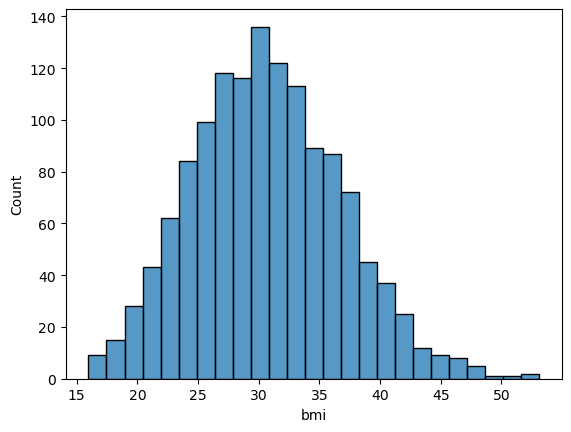

In [78]:
sns.histplot(df['bmi'])

In [79]:
df_clean['bmi_category'] = pd.cut(df_clean['bmi'],bins=[0,18.5,24.9,29.9,100],labels=['underweight','normal_weight','overweight','obesity'])

In [80]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obesity
2,28,0,33,3,0,4449,0,1,0,obesity
3,33,0,22,0,0,21984,1,0,0,normal_weight
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obesity
1334,18,1,31,0,0,2205,0,0,0,obesity
1335,18,1,36,0,0,1629,0,1,0,obesity
1336,21,1,25,0,0,2007,0,0,1,overweight


In [81]:
df_clean = pd.get_dummies(df_clean,columns=['bmi_category'],drop_first=True)
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal_weight,bmi_category_overweight,bmi_category_obesity
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [82]:
df_clean = df_clean.astype(int)
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal_weight,bmi_category_overweight,bmi_category_obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [84]:
# Linear Regression and Logistic Regression dont work with weighted values so we will convert all the columns into int type

In [85]:
df_clean.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal_weight', 'bmi_category_overweight',
       'bmi_category_obesity'],
      dtype='object')

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['age', 'bmi', 'children']

# make sure the columns are numeric (coerce any non-numeric entries to NaN)
for c in cols:
	df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

# if NaNs exist, try to fill them from the original df (align by index)
if set(cols).issubset(df.columns):
	for c in cols:
		if df_clean[c].isna().any():
			df_clean[c] = df_clean[c].fillna(df.loc[df_clean.index, c])

# final fallback: fill any remaining NaNs with column median
for c in cols:
	if df_clean[c].isna().any():
		df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# scale the numeric columns
df_clean[cols] = scaler.fit_transform(df_clean[cols].astype(float))

df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal_weight,bmi_category_overweight,bmi_category_obesity
0,-1.440418,1,-0.453160,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866,1,0,0,0,1,0


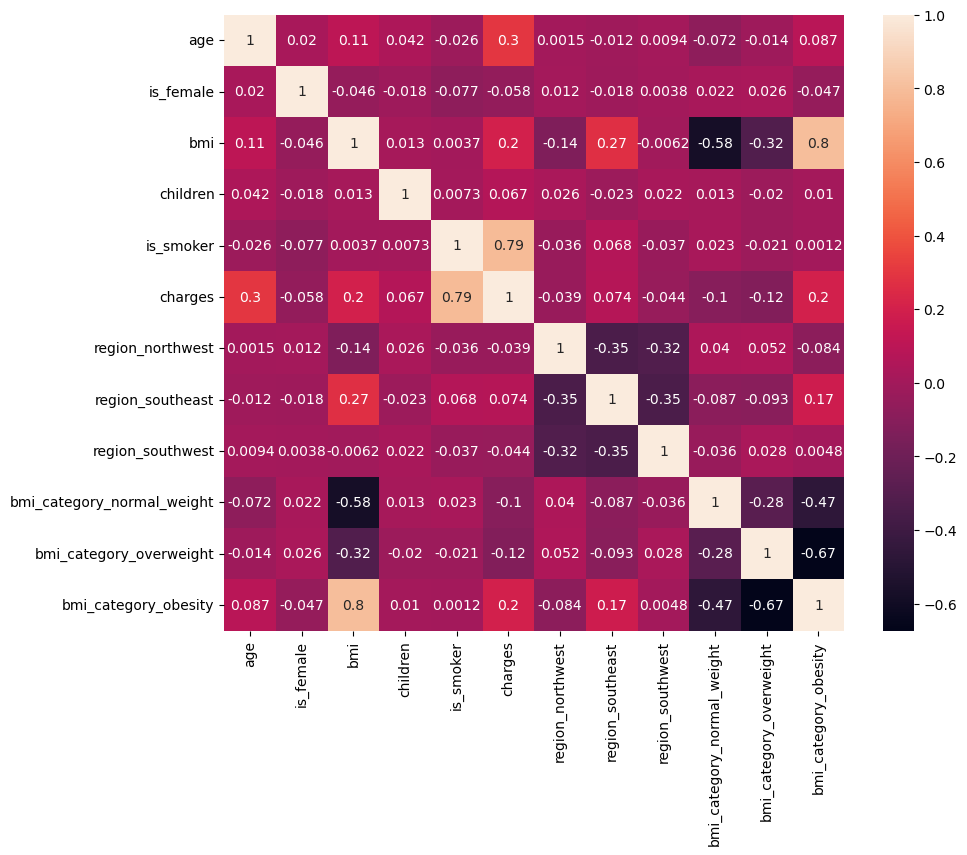

In [92]:
# find the corelation again

plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)
plt.show()
